# Импорты

In [38]:
import os
import torch
import torch.nn as nn
import math
import torch.nn.functional as F
from tqdm import tqdm
import torch.utils.data as data

from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.normalizers import Lowercase
from tokenizers.decoders import BPEDecoder
from transformers import PreTrainedTokenizerFast

device = "cuda" if torch.cuda.is_available() else "cpu"

import matplotlib.pyplot as plt
import numpy as np

# Реализация

Реализация Self-Attention Head

In [39]:
class SelfAttention(nn.Module):
    def __init__(self, d_model, d_head, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.d_head = d_head
        self.dropout = dropout

        mean = 0.0
        std = math.sqrt(2.0 / (self.d_model + self.d_head))

        self.W_Q = nn.Parameter(torch.empty(d_model, d_head).normal_(mean, std))
        self.W_K = nn.Parameter(torch.empty(d_model, d_head).normal_(mean, std))
        self.W_V = nn.Parameter(torch.empty(d_model, d_head).normal_(mean, std))
        self.dropoutA = nn.Dropout(self.dropout)

    def forward(self, X):
        Q = X @ self.W_Q
        K = X @ self.W_K
        V = X @ self.W_V

        S = (Q @ K.transpose(-1, -2)) / math.sqrt(self.d_head)

        causal_mask = ~torch.tril(torch.ones_like(S, dtype=torch.bool))
        S = S.masked_fill(causal_mask, -torch.inf)
        S = torch.softmax(S, dim=-1)

        A = S @ V

        return self.dropoutA(A)

Реализация MultiHeadAttention

In [40]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, d_head, num_heads, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.d_head = d_head
        self.num_heads = num_heads
        self.dropout = dropout

        self.heads = nn.ModuleList(
            [SelfAttention(self.d_model, self.d_head, self.dropout) for _ in range(self.num_heads)]
        )
        self.proj = nn.Linear(self.d_model, self.d_model)
        self.dropoutMHA = nn.Dropout(self.dropout)

    def forward(self, X):
        X = torch.concat([head(X) for head in self.heads], dim=-1)
        X = self.proj(X)

        return self.dropoutMHA(X)

Реализация LayerNorm

In [41]:
class LayerNorm(nn.Module):
    def __init__(self, d_model, epsilon=1e-6):
        super().__init__()
        self.d_model = d_model
        self.epsilon = epsilon

        self.gamma = nn.Parameter(torch.ones(d_model))
        self.beta = nn.Parameter(torch.zeros(d_model))

    def forward(self, X):
        mean = torch.mean(X, dim=-1, keepdim=True)
        var = torch.var(X, dim=-1, unbiased=False, keepdim=True)

        X = ((X - mean) / torch.sqrt(var + self.epsilon)) * self.gamma + self.beta

        return X

Реализация FeedForward

In [42]:
class FeedForward(nn.Module):
    def __init__(self, d_model, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.dropout = dropout

        self.layer1 = nn.Linear(self.d_model, 4 * self.d_model)
        self.act = nn.ReLU()
        self.layer2 = nn.Linear(4 * self.d_model, self.d_model)
        self.dropoutFF = nn.Dropout(self.dropout)

    def forward(self, X):
        X = self.layer2(
            self.act(
                self.layer1(X)
            )
        )

        return self.dropoutFF(X)

Реализация PositionalEncoding

In [43]:
class PositionalEncoding(nn.Module):
    def __init__(self, max_context_length, d_model):
        super().__init__()
        self.max_context_length = max_context_length
        self.d_model = d_model

        mean = 0.0
        std = math.sqrt(1.0 / self.d_model)

        self.position_codes = nn.Parameter(torch.empty(self.max_context_length, self.d_model).normal_(mean, std))

    def forward(self, seq_length):
        return self.position_codes[:seq_length]

Реализация Embedding Layer

In [44]:
class EmbeddingLayer(nn.Module):
    def __init__(self, vocab_size, d_model):
        super().__init__()
        self.vocab_size = vocab_size
        self.d_model = d_model

        mean = 0.0
        std = math.sqrt(1.0 / self.d_model)

        self.embeddings = nn.Parameter(torch.empty(self.vocab_size, self.d_model).normal_(mean, std))

    def forward(self, token_ids):
        return self.embeddings[token_ids]

Реализация Encoder блока

In [45]:
class Encoder(nn.Module):
    def __init__(self, d_model, num_heads, d_head, dropout=0.1, epsilon=1e-6):
        super().__init__()
        self.d_model = d_model if d_model % num_heads == 0 else d_model // num_heads * num_heads
        self.num_heads = num_heads
        self.d_head = d_head
        self.dropout = dropout
        self.epsilon = epsilon

        self.layerNormPreMHA = LayerNorm(self.d_model, self.epsilon)
        self.multiHeadAttention = MultiHeadAttention(self.d_model, self.d_head, self.num_heads, self.dropout)
        self.layerNormPreFF = LayerNorm(self.d_model, self.epsilon)
        self.feedForward = FeedForward(self.d_model, self.dropout)

    def forward(self, embeddings):
        embeddings = embeddings + self.multiHeadAttention(self.layerNormPreMHA(embeddings))
        embeddings = embeddings + self.feedForward(self.layerNormPreFF(embeddings))

        return embeddings

Реализация GPT

In [46]:
class GPT(nn.Module):
    def __init__(self, max_context_length, num_encoder_blocks, vocab_size, d_model, num_heads, dropout=0.1):
        super().__init__()
        self.max_context_length = max_context_length
        self.num_encoder_blocks = num_encoder_blocks
        self.vocab_size = vocab_size
        self.d_model = d_model if d_model % num_heads == 0 else d_model // num_heads * num_heads
        self.num_heads = num_heads
        self.d_head = self.d_model // self.num_heads
        self.dropout = dropout
        self.epsilon = 1e-6

        self.embeddingLayer = EmbeddingLayer(self.vocab_size, self.d_model)
        self.positionalEnconding = PositionalEncoding(self.max_context_length, self.d_model)

        self.encoders = nn.ModuleList(
            [Encoder(self.d_model, self.num_heads, self.d_head, self.dropout, self.epsilon) for _ in range(self.num_encoder_blocks)]
        )

        self.finalLayerNorm = LayerNorm(self.d_model, self.epsilon)
        self.embeddings2ids = nn.Linear(self.d_model, self.vocab_size)

    def forward(self, batch_token_ids):
        seq_length = batch_token_ids.size(1)
        embeddings = self.embeddingLayer(batch_token_ids) + self.positionalEnconding(seq_length)

        encoder_outputs = embeddings
        for encoder in self.encoders:
            encoder_outputs = encoder(encoder_outputs)

        encoder_outputs = self.finalLayerNorm(encoder_outputs)
        gen_batch_token_ids = self.embeddings2ids(encoder_outputs)

        return gen_batch_token_ids

    def generate(self, start_token_ids, num_gen_tokens):
        squeeze_output = start_token_ids.dim() == 1
        gen_token_ids = start_token_ids.unsqueeze(0) if squeeze_output else start_token_ids

        for _ in range(num_gen_tokens):
            context = gen_token_ids[:, -self.max_context_length:]
            seq_length = context.size(1)

            embeddings = self.embeddingLayer(context) + self.positionalEnconding(seq_length)

            encoder_outputs = embeddings
            for encoder in self.encoders:
                encoder_outputs = encoder(encoder_outputs)

            encoder_outputs = self.finalLayerNorm(encoder_outputs)
            gen_token_probabilities = F.softmax(self.embeddings2ids(encoder_outputs)[:, -1], dim=-1)
            gen_token_id = torch.multinomial(gen_token_probabilities, num_samples=1)

            gen_token_ids = torch.concat([gen_token_ids, gen_token_id], dim=-1)

        return gen_token_ids.squeeze(0) if squeeze_output else gen_token_ids

Кастомный токенизатор

In [47]:
class MyTokenizerMaker:
    def __init__(self, text, vocab_size, save_dir):
        self.text = text
        self.vocab_size = vocab_size
        self.save_dir = save_dir

        self.__make_tokenizer__()
        self.__make_PyTorch_like_tokenizer__()
        self.__save_tokenzier__()

    def _iter_text_chunks(self, chunk_size=10000):
        for i in range(0, len(self.text), chunk_size):
            chunk = self.text[i:i + chunk_size].strip()
            if chunk:
                yield chunk

    def __make_tokenizer__(self):
        self.tokenizer = Tokenizer(
            BPE(
                unk_token="[UNK]",
                end_of_word_suffix="</w>",
            )
        )
        self.tokenizer.normalizer = Lowercase()
        self.tokenizer.pre_tokenizer = Whitespace()
        self.tokenizer.decoder = BPEDecoder(suffix="</w>")

        special_tokens = [
            "[PAD]",
            "[UNK]",
            "[BOS]",
            "[EOS]",
        ]

        self.trainer = BpeTrainer(
            vocab_size=self.vocab_size,
            min_frequency=2,
            special_tokens=special_tokens,
            show_progress=True,
            end_of_word_suffix="</w>",
        )

        self.tokenizer.train_from_iterator(
            self._iter_text_chunks(),
            trainer=self.trainer,
        )

    def __make_PyTorch_like_tokenizer__(self):
        self.hf_tokenizer = PreTrainedTokenizerFast(
            tokenizer_object=self.tokenizer,
            unk_token="[UNK]",
            pad_token="[PAD]",
            bos_token="[BOS]",
            eos_token="[EOS]",
        )

    def __save_tokenzier__(self):
        self.hf_tokenizer.save_pretrained(f"{self.save_dir}/tokenizer")

    def get_tokenizer(self):
        return self.hf_tokenizer

Кастомный датасет

In [48]:
class BookDataset(nn.Module):
    def __init__(self, tokenizer, context_size, book, is_test, test_size=0.9):
        self.tokenizer = tokenizer
        self.context_size = context_size
        self.book = book
        self.is_test = is_test
        self.test_size = test_size

        self.dataset = torch.tensor(self.tokenizer.encode(self.book), dtype=torch.long)

        board = int(self.dataset.size(-1) * self.test_size)
        if is_test:
            self.dataset = self.dataset[board:]
        else:
            self.dataset = self.dataset[:board]

        self.length = (self.dataset.size(-1) - self.context_size) // self.context_size

    def __getitem__(self, item):
        l1 = item*self.context_size
        r1 = (item+1)*self.context_size
        l2 = item*self.context_size+1
        r2 = (item+1)*self.context_size+1

        return self.dataset[l1:r1], self.dataset[l2:r2]

    def __len__(self):
        return self.length

# Использование

Где будет запускаться ноутбук: личный пк или google colab

In [49]:
place_of_work = "pc"
# place_of_work = "pc"

In [50]:
save_dir = "."

if place_of_work == "colab":
    if os.path.exists("/content"):
        drive_root = "/content/drive"
        my_drive_dir = os.path.join(drive_root, "MyDrive")
        if not os.path.isdir(my_drive_dir):
            try:
                from google.colab import drive
                drive.mount(drive_root)
            except ImportError:
                pass
        if os.path.isdir(my_drive_dir):
            save_dir = os.path.join(my_drive_dir, "nlp_homework_1")
else:
    save_dir = os.path.join(save_dir, "results")

os.makedirs(save_dir, exist_ok=True)

train_losses_path = os.path.join(save_dir, "gpt_pre-norm_train_losses.npy")
test_losses_path = os.path.join(save_dir, "gpt_pre-norm_test_losses.npy")
model_state_dict_path = os.path.join(save_dir, "gpt_pre-norm_state_dict.pt")

Некоторые параметры

In [51]:
book_path = "book.txt"

vocab_size = 32000
max_context_length = 50

Загружаем книгу и создаём токенизатор

In [52]:
with open(book_path, 'r', encoding='utf-8') as f:
    book = f.read()

tokenizer = MyTokenizerMaker(book, vocab_size, save_dir).get_tokenizer()

Создаём датасет

In [53]:
d_train = BookDataset(tokenizer, max_context_length, book, False)
d_test = BookDataset(tokenizer, max_context_length, book, True)

train_data = data.DataLoader(d_train, batch_size=16, shuffle=True)
test_data = data.DataLoader(d_test, batch_size=16, shuffle=False)

Создаём модель

In [54]:
num_encoder_blocks = 7
d_model = 200
num_heads = 5
dropout = 0.1

In [55]:
model  = GPT(
    max_context_length,
    num_encoder_blocks,
    vocab_size,
    d_model,
    num_heads,
    dropout
).to(device)

optimizer = torch.optim.Adam(params=model.parameters(), lr=3e-4)
criterion = torch.nn.CrossEntropyLoss()

use_amp = device == "cuda"
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

Обучаем

In [56]:
epochs = 10

train_losses = []
test_losses = []

for epoch in range(1, epochs+1):
    running_loss = 0.0
    num_batches = 0

    train_bar = tqdm(
        train_data,
        total=len(train_data),
        desc=f"Epoch {epoch}/{epochs}",
        leave=False,
    )

    model.train()
    for input_ids, target_ids in train_bar:
        input_ids = input_ids.to(device)
        target_ids = target_ids.to(device)

        optimizer.zero_grad()
        with torch.amp.autocast("cuda", enabled=use_amp):
            logits = model(input_ids).permute(0, 2, 1)
            loss = criterion(logits, target_ids)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        loss_value = loss.item()
        running_loss += loss_value
        num_batches += 1

        train_bar.set_postfix(
            loss=f"{loss_value:.4f}",
            avg_loss=f"{running_loss / num_batches:.4f}",
        )

    model.eval()
    test_running_loss = 0.0
    test_num_batches = 0

    with torch.no_grad():
        for input_ids, target_ids in test_data:
            input_ids = input_ids.to(device)
            target_ids = target_ids.to(device)

            with torch.amp.autocast("cuda", enabled=use_amp):
                logits = model(input_ids).permute(0, 2, 1)
                loss = criterion(logits, target_ids)

            test_running_loss += loss.item()
            test_num_batches += 1

    train_loss = running_loss / num_batches
    test_loss = test_running_loss / test_num_batches

    if not train_losses or train_loss <= min(train_losses):
        torch.save(model.state_dict(), model_state_dict_path)

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    np.save(train_losses_path, np.array(train_losses, dtype=np.float32))
    np.save(test_losses_path, np.array(test_losses, dtype=np.float32))

    print(
        f"Epoch {epoch}/{epochs} | train_loss={train_loss:.4f} | test_loss={test_loss:.4f}"
    )

Epoch 1/10 | train_loss=7.5207 | test_loss=7.3793


Epoch 2/10 | train_loss=6.9262 | test_loss=7.2081


Epoch 3/10 | train_loss=6.6545 | test_loss=7.1321


Epoch 4/10 | train_loss=6.4046 | test_loss=7.1480


Epoch 5/10 | train_loss=6.1543 | test_loss=7.2502


Epoch 6/10 | train_loss=5.8966 | test_loss=7.3598


Epoch 7/10 | train_loss=5.6388 | test_loss=7.4817


Epoch 8/10 | train_loss=5.3763 | test_loss=7.6753


Epoch 9/10 | train_loss=5.1131 | test_loss=7.8057


Epoch 10/10 | train_loss=4.8419 | test_loss=8.0399


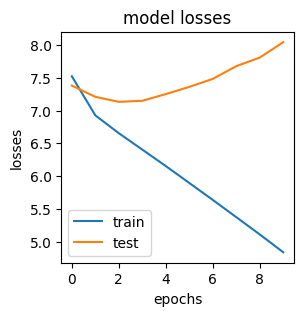

In [57]:
plt.figure(figsize=(3, 3))
plt.title("model losses")
plt.plot(range(epochs), train_losses, label="train")
plt.plot(range(epochs), test_losses, label="test")
plt.xlabel("epochs")
plt.ylabel("losses")
plt.legend()
plt.savefig("base_model_losses.png")
plt.show()

In [58]:
# model_state_dict = torch.load("./results/base_model_state_dict.pt", map_location="cpu")
# model = GPT(max_context_length, num_encoder_blocks, vocab_size, d_model, num_heads, dropout)
# model.load_state_dict(model_state_dict)

In [59]:
model.eval()

GPT(
  (embeddingLayer): EmbeddingLayer()
  (positionalEnconding): PositionalEncoding()
  (encoders): ModuleList(
    (0-6): 7 x Encoder(
      (layerNormPreMHA): LayerNorm()
      (multiHeadAttention): MultiHeadAttention(
        (heads): ModuleList(
          (0-4): 5 x SelfAttention(
            (dropoutA): Dropout(p=0.1, inplace=False)
          )
        )
        (proj): Linear(in_features=200, out_features=200, bias=True)
        (dropoutMHA): Dropout(p=0.1, inplace=False)
      )
      (layerNormPreFF): LayerNorm()
      (feedForward): FeedForward(
        (layer1): Linear(in_features=200, out_features=800, bias=True)
        (act): ReLU()
        (layer2): Linear(in_features=800, out_features=200, bias=True)
        (dropoutFF): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (finalLayerNorm): LayerNorm()
  (embeddings2ids): Linear(in_features=200, out_features=32000, bias=True)
)

In [60]:
d_train[200][0]

tensor([ 3074,   661,   112,  6780,   162,  6222,   126,   214,  1359,   126,
          243,   517,    93,   330, 15451,   277,  3090,   102, 16157,  4193,
        14976,  1141,   112, 12271,  6218,   126,   214, 20456, 16126,    91,
        22604,   126,  5302,  7299,    93,  2720,   112,   246,  1407, 10587,
         3319, 20296,  8365,   126,    93,   400,  1848,   136,  1117,  2996])

In [61]:
tokenizer.decode(model.generate(torch.tensor([[3074]], device=device), 200).tolist())

['остался нужно видишь , нерешительно , которые наследник вырваться . в порядке домой , когда - короля . там стояли никто не разлей безумие . бойня , как люди , но также пора словах . в ответ , что уже не оказалось томада ни с разисходит для начала . с ним из у нее налево . острая мимо . брис беддикт уткне понимаешь , словно морская пробежал . меч . тисте эдур с этому тени – все такое вопрос . – что ему один на запрел . – да , на ждает нагнулся в сторону эрбат . нужно аль . поэтому да , вы пробормотал бурук посмотрел на юг . – постробрата . урут , я цена канаочагу лицо . – ресидели на всех . – летерийский голосом . – демон ! – собирался племена к бесцветчевать не прав , – пробормотал трулл сэнгар , шурк . – брис поднял кенрилл ’ ра . но теперь не знают . еще меня ты более ллы ? это его из женщин . – я это уже попадет , когда - либо жить о вашей ка , удинаас вещах даже раз как ты рисудные всех превратится']

In [62]:
print(sum(p.numel() for p in model.parameters())/1e6, 'M parameters')

16.2164 M parameters
